# Roof Outline Instance Segmentation — YOLO26-seg

Trains a YOLO segmentation model to segment the **whole roof outline** (single class: `roof`) from the RID-style dataset (`roof_information_dataset_2`).

**How labels are built:** your dataset stores roof outlines as *vector* polygons in real-world coordinates (`geometries/gdf_all_outlines.json`, CRS `EPSG:28992` — Dutch RD New), not as pixel masks. Each 512×512 image tile also has a known real-world bounding box (`geometries/gdf_images_with_labels_512.json`). This notebook:

1. Spatially joins every outline polygon against every labeled tile.
2. Clips outlines to the tile edges (buildings that straddle a tile boundary get cut cleanly instead of producing bad labels).
3. Converts the clipped polygon from world coordinates → pixel coordinates → normalized YOLO segmentation format.
4. Builds a proper `images/`, `labels/`, `data.yaml` YOLO dataset.
5. **Includes a visual sanity check before training** — this is the step that catches a wrong coordinate transform (flipped/mirrored/shifted polygons). Don't skip it.
6. Trains YOLO26-seg with CUDA.

### Assumptions made (please verify in the sanity-check cell, and tell me if any look wrong)
- Tile id / bounding box top-left = `(min_x, max_y)` — i.e. images are north-up with row 0 = north, standard for this kind of ortho imagery.
- Only **train** and **test** splits were provided, so a validation set (12%) is carved out of the training split at random. The test split stays untouched for final evaluation.
- Roof outlines are treated as **exterior boundary only** — if any polygons have interior holes (e.g. courtyards), the hole is dropped, since standard YOLO segmentation polygons don't support holes.
- Images are matched to tile geometry by filename stem (tries `.png/.jpg/.jpeg/.tif/.tiff`).

Edit the `DATASET_ROOT` path in the config cell, then run top to bottom.

In [1]:
!uv pip install -q ultralytics geopandas shapely pandas tqdm matplotlib pillow geopandas

In [2]:
import sys
!{sys.executable} -m pip install geopandas

Defaulting to user installation because normal site-packages is not writeable


In [3]:
import json
import random
import shutil
from pathlib import Path

import geopandas as gpd
import pandas as pd
import torch
from shapely.geometry import Polygon
from shapely.geometry.base import BaseGeometry
from tqdm import tqdm

print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("WARNING: no CUDA GPU detected by torch. Training will fall back to CPU and be very slow.")
    print("If you have an NVIDIA GPU, install a CUDA build of torch, e.g.:")
    print("  pip uninstall -y torch torchvision torchaudio")
    print("  pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121")


CUDA available: True
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


In [4]:
# ==================== CONFIG — edit this ====================
DATASET_ROOT = Path(r"C:\Users\Jeobel\Downloads\Roof-Type-Classifier.v1i.folder")

IMAGES_DIR    = DATASET_ROOT / "images"
GEOM_DIR      = DATASET_ROOT / "geometries"
OUTLINES_JSON = GEOM_DIR / "gdf_all_outlines.json"
TILES_JSON    = GEOM_DIR / "gdf_images_with_labels_512.json"
TRAIN_CSV     = DATASET_ROOT / "training_split_512.csv"
TEST_CSV      = DATASET_ROOT / "test_split_512.csv"

OUTPUT_DIR    = DATASET_ROOT / "yolo_roof_outline_dataset"

CLASS_NAMES   = ["roof"]
IMG_EXTS      = [".png", ".jpg", ".jpeg", ".tif", ".tiff"]

VAL_FRACTION     = 0.12
RANDOM_SEED      = 42
MIN_POLY_AREA_PX = 9.0     # discard slivers smaller than this after clipping to tile edges
SIMPLIFY_TOL_PX  = 0.75    # shapely simplify tolerance in pixels (0 disables)
# ==============================================================


## 1. Load the vector geometries

In [5]:
def load_geojson_manual(path):
    """Load a GeoJSON-with-old-style-CRS file into a GeoDataFrame without relying on
    fiona/pyogrio's own (sometimes finicky) CRS parsing."""
    from shapely.geometry import shape

    with open(path) as f:
        data = json.load(f)
    crs = data.get("crs", {}).get("properties", {}).get("name")
    records = []
    for feat in data["features"]:
        geom = shape(feat["geometry"])
        props = dict(feat["properties"])
        props["geometry"] = geom
        records.append(props)
    gdf = gpd.GeoDataFrame(records, geometry="geometry")
    if crs:
        gdf.set_crs(crs, inplace=True, allow_override=True)
    return gdf


outlines_gdf = load_geojson_manual(OUTLINES_JSON)
tiles_gdf = load_geojson_manual(TILES_JSON)

print(f"Loaded {len(outlines_gdf)} outline polygons")
print(f"Loaded {len(tiles_gdf)} labeled tiles")
print("Outline bounds:", outlines_gdf.total_bounds)
print("Tile bounds:   ", tiles_gdf.total_bounds)

ob, tb = outlines_gdf.total_bounds, tiles_gdf.total_bounds
assert ob[0] < tb[2] and ob[2] > tb[0] and ob[1] < tb[3] and ob[3] > tb[1], (
    "Outline and tile bounding boxes do not overlap at all — "
    "check both files are for the same area/CRS before continuing."
)
print("Sanity check passed: outline and tile extents overlap.")


Loaded 14701 outline polygons
Loaded 4764 labeled tiles
Outline bounds: [ 22233.6912 363246.9408 250979.552  578995.7288]
Tile bounds:    [ 22242.         363280.77135515 250996.83355369 578987.98758834]
Sanity check passed: outline and tile extents overlap.


## 2. World-coordinate → pixel-coordinate → YOLO polygon conversion

In [6]:
def world_to_pixel(x, y, minx, maxy, res_x, res_y):
    """(min_x, max_y) is assumed to be the tile's top-left corner in pixel space
    (north-up image). Verified visually in the sanity-check cell below."""
    px = (x - minx) / res_x
    py = (maxy - y) / res_y
    return px, py


def polygons_from_geom(geom: BaseGeometry):
    if geom is None or geom.is_empty:
        return []
    if geom.geom_type == "Polygon":
        return [geom]
    if geom.geom_type == "MultiPolygon":
        return list(geom.geoms)
    if geom.geom_type == "GeometryCollection":
        out = []
        for g in geom.geoms:
            out.extend(polygons_from_geom(g))
        return out
    return []  # ignore stray Point/LineString slivers from edge-touching intersections


def tile_polygons_to_yolo_lines(tile_geom, outline_geoms, width_px, height_px,
                                 class_id=0, min_area_px=MIN_POLY_AREA_PX,
                                 simplify_tol_px=SIMPLIFY_TOL_PX):
    tminx, tminy, tmaxx, tmaxy = tile_geom.bounds
    res_x = (tmaxx - tminx) / width_px
    res_y = (tmaxy - tminy) / height_px
    lines = []
    for og in outline_geoms:
        inter = og.intersection(tile_geom)
        for poly in polygons_from_geom(inter):
            if poly.area <= 0 or poly.exterior is None:
                continue
            coords = list(poly.exterior.coords)[:-1]
            px_coords = [world_to_pixel(x, y, tminx, tmaxy, res_x, res_y) for x, y in coords]
            px_poly = Polygon(px_coords)
            if not px_poly.is_valid or px_poly.area < min_area_px:
                continue
            if simplify_tol_px > 0:
                simplified = px_poly.simplify(simplify_tol_px, preserve_topology=True)
                if (not simplified.is_empty) and simplified.geom_type == "Polygon":
                    px_coords = list(simplified.exterior.coords)[:-1]
            if len(px_coords) < 3:
                continue
            norm = []
            for px, py in px_coords:
                nx = min(max(px / width_px, 0.0), 1.0)
                ny = min(max(py / height_px, 0.0), 1.0)
                norm.extend([nx, ny])
            lines.append(f"{class_id} " + " ".join(f"{v:.6f}" for v in norm))
    return lines


## 3. Generate labels for every tile (spatial join)

In [7]:
import shapely
from shapely.errors import GEOSException
from tqdm.auto import tqdm

# Ensure both layers use the same coordinate reference system
if outlines_gdf.crs != tiles_gdf.crs:
    outlines_gdf = outlines_gdf.to_crs(tiles_gdf.crs)

# Remove missing or empty roof geometries
outlines_gdf = outlines_gdf[
    outlines_gdf.geometry.notna() &
    ~outlines_gdf.geometry.is_empty
].copy()

# Repair invalid roof polygons before building sindex
outlines_gdf["geometry"] = outlines_gdf.geometry.apply(shapely.make_valid)

# Keep only usable repaired geometries
outlines_gdf = outlines_gdf[
    outlines_gdf.geometry.notna() &
    ~outlines_gdf.geometry.is_empty
].copy()

# Repair tile geometries too
tiles_gdf = tiles_gdf[
    tiles_gdf.geometry.notna() &
    ~tiles_gdf.geometry.is_empty
].copy()

tiles_gdf["geometry"] = tiles_gdf.geometry.apply(shapely.make_valid)

print("Invalid roof geometries:", (~outlines_gdf.geometry.is_valid).sum())
print("Invalid tile geometries:", (~tiles_gdf.geometry.is_valid).sum())

# Build this only AFTER geometry repair
sindex = outlines_gdf.sindex

tile_labels = {}
empty_tiles = []
failed_tiles = []

for _, tile in tqdm(
    tiles_gdf.iterrows(),
    total=len(tiles_gdf),
    desc="Generating labels"
):
    tile_id = tile["id"]
    tile_geom = tile.geometry

    width_px = int(tile.get("image_width_px", 512))
    height_px = int(tile.get("image_height_px", 512))

    try:
        candidate_idx = list(
            sindex.query(tile_geom, predicate="intersects")
        )

        candidate_geoms = outlines_gdf.geometry.iloc[candidate_idx].tolist()

        lines = tile_polygons_to_yolo_lines(
            tile_geom,
            candidate_geoms,
            width_px,
            height_px
        )

    except GEOSException as e:
        print(f"\nSkipping tile {tile_id}: {e}")
        lines = []
        failed_tiles.append(tile_id)

    tile_labels[tile_id] = lines

    if not lines:
        empty_tiles.append(tile_id)

print(
    f"{len(tile_labels)} tiles processed, "
    f"{len(empty_tiles)} ended up with zero roof polygons"
)

if empty_tiles:
    print("Example empty tiles:", empty_tiles[:5])

if failed_tiles:
    print(f"{len(failed_tiles)} tiles failed due to geometry errors")
    print("Example failed tiles:", failed_tiles[:5])

C:\Users\Jeobel\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Invalid roof geometries: 0
Invalid tile geometries: 0


Generating labels: 100%|██████████| 4764/4764 [00:06<00:00, 745.87it/s] 

4764 tiles processed, 21 ended up with zero roof polygons
Example empty tiles: ['138177.81_441369.46', '138792.21_441779.06', '176376.87_363362.69', '225001.0_568138.84', '225615.4_568753.24']


## 4. Match image files and build train/val/test splits

In [8]:
def find_image_file(stem):
    for ext in IMG_EXTS:
        for cand in (IMAGES_DIR / f"{stem}{ext}", IMAGES_DIR / f"{stem}{ext.upper()}"):
            if cand.exists():
                return cand
    return None


def stem_from_name(name):
    return Path(str(name)).stem


train_df = pd.read_csv(TRAIN_CSV)
test_df = pd.read_csv(TEST_CSV)
print("train csv columns:", list(train_df.columns))
print("test csv columns:", list(test_df.columns))

name_col = "image_names" if "image_names" in train_df.columns else train_df.columns[-1]

train_stems_all = [stem_from_name(n) for n in train_df[name_col]]
test_stems = [stem_from_name(n) for n in test_df[name_col]]

random.seed(RANDOM_SEED)
shuffled = train_stems_all.copy()
random.shuffle(shuffled)
n_val = int(len(shuffled) * VAL_FRACTION)
val_stems = shuffled[:n_val]
train_stems = shuffled[n_val:]

print(f"train: {len(train_stems)}  val: {len(val_stems)}  test: {len(test_stems)}")


train csv columns: ['Unnamed: 0', 'image_names']
test csv columns: ['Unnamed: 0', 'image_names']
train: 3355  val: 457  test: 952


## 5. Materialize the YOLO dataset (copy images, write label .txt files)

In [9]:
def build_split(stems, split_name):
    img_out = OUTPUT_DIR / "images" / split_name
    lbl_out = OUTPUT_DIR / "labels" / split_name
    img_out.mkdir(parents=True, exist_ok=True)
    lbl_out.mkdir(parents=True, exist_ok=True)

    n_ok = n_missing_img = n_missing_tile = 0
    for stem in tqdm(stems, desc=f"Building {split_name}"):
        src_img = find_image_file(stem)
        if src_img is None:
            n_missing_img += 1
            continue
        if stem not in tile_labels:
            n_missing_tile += 1
            continue
        shutil.copy2(src_img, img_out / src_img.name)
        (lbl_out / f"{stem}.txt").write_text("\n".join(tile_labels[stem]))
        n_ok += 1

    print(f"[{split_name}] copied {n_ok} | missing image file: {n_missing_img} | "
          f"missing tile geometry: {n_missing_tile}")


build_split(train_stems, "train")
build_split(val_stems, "val")
build_split(test_stems, "test")


Building train: 100%|██████████| 3355/3355 [00:14<00:00, 235.74it/s]


[train] copied 3355 | missing image file: 0 | missing tile geometry: 0


Building val: 100%|██████████| 457/457 [00:01<00:00, 229.76it/s]


[val] copied 457 | missing image file: 0 | missing tile geometry: 0


Building test: 100%|██████████| 952/952 [00:03<00:00, 255.31it/s]

[test] copied 952 | missing image file: 0 | missing tile geometry: 0


In [10]:
yaml_content = f"""path: {OUTPUT_DIR.as_posix()}
train: images/train
val: images/val
test: images/test

names:
  0: roof
"""
(OUTPUT_DIR / "data.yaml").write_text(yaml_content)
print(yaml_content)


path: C:/Users/Jeobel/Downloads/Roof-Type-Classifier.v1i.folder/yolo_roof_outline_dataset
train: images/train
val: images/val
test: images/test

names:
  0: roof



## 6. ⚠️ Sanity check — verify the labels actually line up with the roofs

**Do not skip this.** If the red outlines don't hug real roof edges — e.g. they're shifted, mirrored, or rotated — the coordinate-transform assumption is wrong for this imagery and needs fixing before training on it.

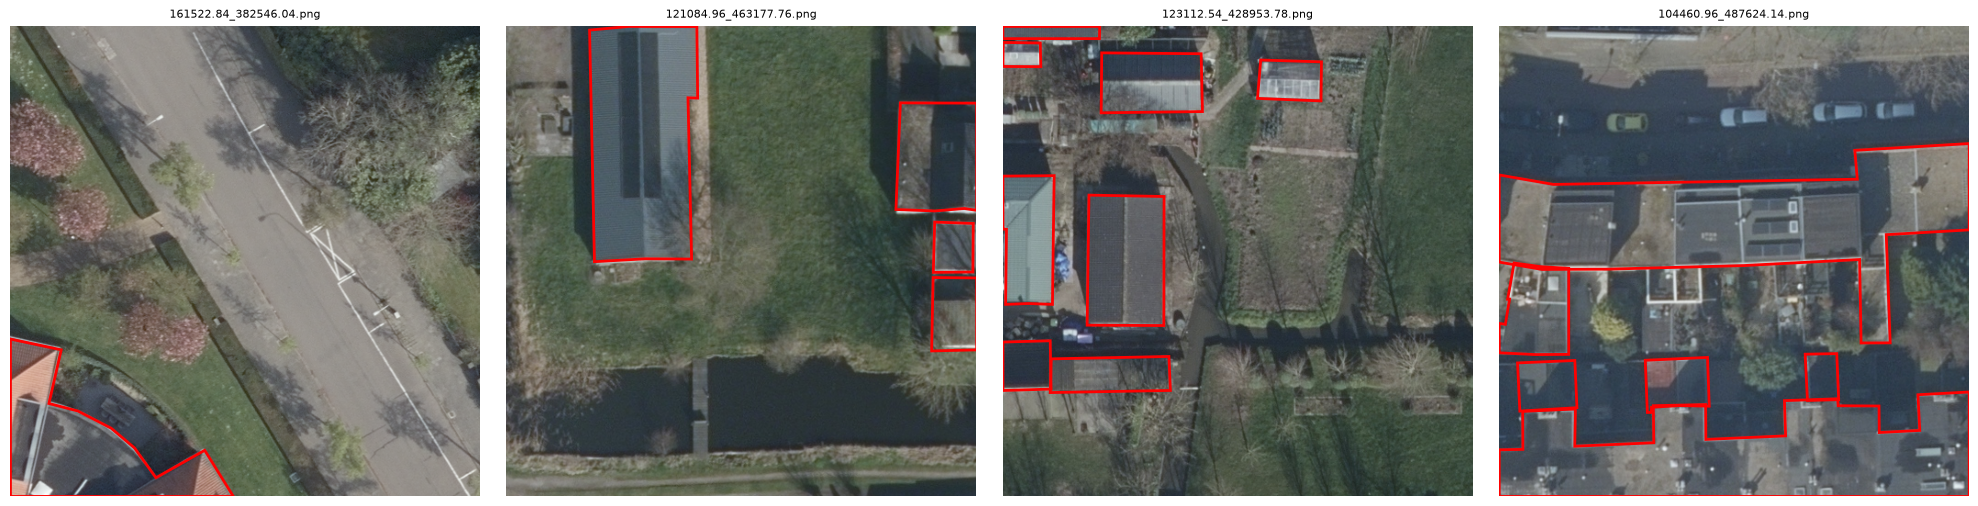

In [11]:
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon as MplPolygon
from PIL import Image

sample_dir = OUTPUT_DIR / "images" / "train"
all_imgs = list(sample_dir.glob("*"))
sample_files = random.sample(all_imgs, min(4, len(all_imgs)))

fig, axes = plt.subplots(1, len(sample_files), figsize=(5 * len(sample_files), 5))
if len(sample_files) == 1:
    axes = [axes]

for ax, img_path in zip(axes, sample_files):
    img = Image.open(img_path)
    w, h = img.size
    ax.imshow(img)
    label_path = OUTPUT_DIR / "labels" / "train" / f"{img_path.stem}.txt"
    if label_path.exists():
        for line in label_path.read_text().splitlines():
            if not line.strip():
                continue
            vals = list(map(float, line.split()))
            coords = vals[1:]
            pts = [(coords[i] * w, coords[i + 1] * h) for i in range(0, len(coords), 2)]
            ax.add_patch(MplPolygon(pts, closed=True, fill=False, edgecolor="red", linewidth=2))
    ax.set_title(img_path.name, fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.show()


In [13]:
from ultralytics import YOLO

device = 0 if torch.cuda.is_available() else "cpu"

model = YOLO("yolo26s-seg.pt")  

train_results = model.train(
    data=str(OUTPUT_DIR / "data.yaml"),
    epochs=150,
    imgsz=512,
    batch=16,
    device=device,
    patience=25,
    project=str(OUTPUT_DIR / "runs"),
    name="roof_outline_seg",
    seed=RANDOM_SEED,
)


New https://pypi.org/project/ultralytics/8.4.91 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.90  Python-3.14.6 torch-2.12.1+cu126 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\Jeobel\Downloads\Roof-Type-Classifier.v1i.folder\yolo_roof_outline_dataset\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mix

## 8. Evaluate on the held-out test split

In [16]:
from pathlib import Path

print("Trainer save directory:", model.trainer.save_dir)

save_dir = Path(model.trainer.save_dir)

print("\nFiles in weights folder:")
for file in (save_dir / "weights").glob("*"):
    print(file)

Trainer save directory: C:\Users\Jeobel\Downloads\Roof-Type-Classifier.v1i.folder\yolo_roof_outline_dataset\runs\roof_outline_seg-9

Files in weights folder:
C:\Users\Jeobel\Downloads\Roof-Type-Classifier.v1i.folder\yolo_roof_outline_dataset\runs\roof_outline_seg-9\weights\best.pt
C:\Users\Jeobel\Downloads\Roof-Type-Classifier.v1i.folder\yolo_roof_outline_dataset\runs\roof_outline_seg-9\weights\last.pt


In [14]:
metrics = model.val(data=str(OUTPUT_DIR / "data.yaml"), split="test", device=device)
print(metrics)


Ultralytics 8.4.90  Python-3.14.6 torch-2.12.1+cu126 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)
YOLO26s-seg summary (fused): 139 layers, 10,365,727 parameters, 0 gradients, 34.1 GFLOPs
WARNING val: Slow image access detected (ping: 0.20.1 ms, read: 41.64.3 MB/s, size: 460.4 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
val: Scanning C:\Users\Jeobel\Downloads\Roof-Type-Classifier.v1i.folder\yolo_roof_outline_dataset\labels\test... 952 images, 6 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 952/952 288.2it/s 3.3s0.0s
val: New cache created: C:\Users\Jeobel\Downloads\Roof-Type-Classifier.v1i.folder\yolo_roof_outline_dataset\labels\test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 60/60 4.1it/s 14.7s0.2s
                   all        952       4183       0.81      0.686      0.7

## 9. Visualize predictions

In [17]:
from pathlib import Path
from ultralytics import YOLO
import random

best_weights = OUTPUT_DIR / "runs" / "roof_outline_seg-9" / "weights" / "best.pt"

print("Loading:", best_weights)
print("Exists:", best_weights.exists())

trained_model = YOLO(str(best_weights))

test_imgs = [
    p for p in (OUTPUT_DIR / "images" / "test").glob("*")
    if p.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
]

print("Test images found:", len(test_imgs))

if not test_imgs:
    raise FileNotFoundError(f"No test images found in: {OUTPUT_DIR / 'images' / 'test'}")

sample = random.sample(test_imgs, min(6, len(test_imgs)))

preds = trained_model.predict(
    source=[str(img) for img in sample],
    imgsz=512,
    device=device,
    conf=0.25
)

for image_path, result in zip(sample, preds):
    print("Showing:", image_path.name)
    result.show()

Loading: C:\Users\Jeobel\Downloads\Roof-Type-Classifier.v1i.folder\yolo_roof_outline_dataset\runs\roof_outline_seg-9\weights\best.pt
Exists: True
Test images found: 952

0: 512x512 1 roof, 16.8ms
1: 512x512 2 roofs, 16.8ms
2: 512x512 5 roofs, 16.8ms
3: 512x512 10 roofs, 16.8ms
4: 512x512 2 roofs, 16.8ms
5: 512x512 11 roofs, 16.8ms
Speed: 1.4ms preprocess, 16.8ms inference, 5.1ms postprocess per image at shape (1, 3, 512, 512)
Showing: 235225.27_578209.75.png
Showing: 193786.3_381220.76.png
Showing: 104747.68_487787.98.png
Showing: 104624.8_487910.86.png
Showing: 120659.56_487511.24.png
Showing: 134564.72_444681.04.png


In [20]:
!pip install ipywidgets -q

## Notes / things you may want to tweak

- **Known limitation:** validation is a random 12% carve-out of the training split. If two adjacent tiles happen to contain the same building, that building could appear in both train and val, slightly inflating val metrics. The held-out `test` split (from `test_split_512.csv`) was never touched during training, so trust that number over val for a true read on generalization.
- **Holes in outlines:** if `gdf_all_outlines.json` turns out to contain polygons with interior rings (courtyards, atria), those holes are currently dropped — only the exterior boundary is kept, since plain YOLO seg polygons can't represent holes.
- **Model size:** started with `yolo26s-seg.pt`. Go to `yolo26n-seg.pt` if you need more speed, or `yolo26m-seg.pt`/`yolo26l-seg.pt` if you have GPU headroom and want higher mask accuracy.
- **`case_study_roof_centered/`** wasn't used here — it looks like a separate held-out qualitative set. Once training looks good, it'd be a good next step to run inference over it (same pixel-matching approach, but using `gdf_images_roof_centered_512_case_study.json` for the tile grid) as an extra visual check.


In [ ]:
import io
from pathlib import Path

import numpy as np
from PIL import Image, ImageDraw
import ipywidgets as widgets
from IPython.display import display, clear_output

# ------------------------------------------------------------
# REQUIRED: trained_model and device must already exist
# Example:
#
from ultralytics import YOLO
best_weights = OUTPUT_DIR / "runs" / "roof_outline_seg-9" / "weights" / "best.pt"
trained_model = YOLO(str(best_weights))
device = 0  
# ------------------------------------------------------------

TILE_SIZE = 2048
OVERLAP = 200
CONFIDENCE = 0.5
IOU = 0.5

# Output folder for exported individual roof crops
EXPORT_DIR = Path(OUTPUT_DIR) / "exported_roof_crops"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)


def make_tiles(image, tile_size=TILE_SIZE, overlap=OVERLAP):
    """
    Split an image into overlapping tiles.

    Each tile keeps its position in the original screenshot so that
    exported roof crops can include original-image coordinates.
    """
    if overlap >= tile_size:
        raise ValueError("OVERLAP must be smaller than TILE_SIZE.")

    width, height = image.size
    stride = tile_size - overlap

    x_positions = list(range(0, max(width - tile_size, 0) + 1, stride))
    y_positions = list(range(0, max(height - tile_size, 0) + 1, stride))

    final_x = max(width - tile_size, 0)
    final_y = max(height - tile_size, 0)

    if not x_positions or x_positions[-1] != final_x:
        x_positions.append(final_x)

    if not y_positions or y_positions[-1] != final_y:
        y_positions.append(final_y)

    tiles = []
    seen = set()

    for top in y_positions:
        for left in x_positions:
            right = min(left + tile_size, width)
            bottom = min(top + tile_size, height)

            key = (left, top, right, bottom)

            if key in seen:
                continue

            seen.add(key)

            tiles.append({
                "image": image.crop((left, top, right, bottom)),
                "left": left,
                "top": top,
                "right": right,
                "bottom": bottom
            })

    return tiles


def draw_tile_grid(image, tiles):
    """Show how the uploaded screenshot was divided into tiles."""
    preview = image.copy()
    draw = ImageDraw.Draw(preview)

    for index, tile in enumerate(tiles, start=1):
        draw.rectangle(
            (
                tile["left"],
                tile["top"],
                tile["right"],
                tile["bottom"]
            ),
            outline="red",
            width=3
        )

        draw.text(
            (tile["left"] + 8, tile["top"] + 8),
            str(index),
            fill="red"
        )

    return preview


def export_roofs_from_tile(result, tile_info, tile_number):
    """
    Export every segmented roof from one tile as a PNG crop.

    The crop uses the segmentation mask, so pixels outside the roof
    are black. Returns how many crops were exported.
    """
    if result.masks is None or result.boxes is None:
        return 0

    if len(result.masks.data) == 0 or len(result.boxes) == 0:
        return 0

    masks = result.masks.data.cpu().numpy()
    boxes = result.boxes.xyxy.cpu().numpy()
    confidences = result.boxes.conf.cpu().numpy()

    tile_width, tile_height = tile_info["image"].size
    tile_array = np.array(tile_info["image"]).copy()

    exported_count = 0

    for roof_index, (mask, box, confidence) in enumerate(
        zip(masks, boxes, confidences),
        start=1
    ):
        # Resize YOLO mask to the exact tile image dimensions
        mask_image = Image.fromarray((mask * 255).astype(np.uint8))
        mask_image = mask_image.resize(
            (tile_width, tile_height),
            resample=Image.Resampling.NEAREST
        )

        mask_array = np.array(mask_image) > 127

        # Ignore empty masks
        if not mask_array.any():
            continue

        # Black background outside the predicted roof
        masked_tile = tile_array.copy()
        masked_tile[~mask_array] = 0

        # Predicted bounding box within this tile
        x1, y1, x2, y2 = map(int, box)

        x1 = max(0, min(x1, tile_width))
        y1 = max(0, min(y1, tile_height))
        x2 = max(0, min(x2, tile_width))
        y2 = max(0, min(y2, tile_height))

        if x2 <= x1 or y2 <= y1:
            continue

        roof_crop = Image.fromarray(masked_tile).crop((x1, y1, x2, y2))

        # Coordinates relative to the original uploaded screenshot
        original_x1 = tile_info["left"] + x1
        original_y1 = tile_info["top"] + y1
        original_x2 = tile_info["left"] + x2
        original_y2 = tile_info["top"] + y2

        filename = (
            f"roof_tile{tile_number:03d}"
            f"_roof{roof_index:03d}"
            f"_conf{confidence:.2f}"
            f"_x{original_x1}-{original_x2}"
            f"_y{original_y1}-{original_y2}.png"
        )

        roof_crop.save(EXPORT_DIR / filename)
        exported_count += 1

    return exported_count


def run_tiled_prediction(image):
    """
    Predict roofs for every tile, display predictions,
    and export each detected roof crop.
    """
    tiles = make_tiles(image)

    print(f"Screenshot size: {image.size[0]} × {image.size[1]}")
    print(f"Tile size: {TILE_SIZE} × {TILE_SIZE}")
    print(f"Overlap: {OVERLAP}px")
    print(f"Tiles created: {len(tiles)}")
    print(f"Export folder: {EXPORT_DIR}")

    print("\nTile layout:")
    display(draw_tile_grid(image, tiles))

    total_detections = 0
    total_exported = 0

    for tile_number, tile_info in enumerate(tiles, start=1):
        result = trained_model.predict(
            source=tile_info["image"],
            imgsz=TILE_SIZE,
            conf=CONFIDENCE,
            iou=IOU,
            device=device,
            verbose=False
        )[0]

        roof_count = len(result.boxes) if result.boxes is not None else 0
        exported_count = export_roofs_from_tile(
            result=result,
            tile_info=tile_info,
            tile_number=tile_number
        )

        total_detections += roof_count
        total_exported += exported_count

        print(
            f"\nTile {tile_number}/{len(tiles)}"
            f" | detected: {roof_count}"
            f" | exported: {exported_count}"
            f" | x={tile_info['left']}–{tile_info['right']}"
            f" | y={tile_info['top']}–{tile_info['bottom']}"
        )

        annotated_tile = result.plot()
        display(Image.fromarray(annotated_tile))

    print("\nFinished.")
    print(f"Total roof detections: {total_detections}")
    print(f"Total exported crops: {total_exported}")
    print(f"Saved to: {EXPORT_DIR}")
    print("Some roofs may be exported more than once because tiles overlap.")


# ------------------------------------------------------------
# Upload interface
# ------------------------------------------------------------

uploader = widgets.FileUpload(
    accept=".jpg,.jpeg,.png,.webp",
    multiple=False,
    description="Upload screenshot"
)

output = widgets.Output()


def on_upload(change):
    if not uploader.value:
        return

    uploaded_file = uploader.value[0]

    file_name = uploaded_file["name"]
    file_bytes = uploaded_file["content"]

    with output:
        clear_output(wait=True)

        image = Image.open(io.BytesIO(file_bytes)).convert("RGB")

        print(f"Uploaded: {file_name}")
        print("Original screenshot:")
        display(image)

        run_tiled_prediction(image)


uploader.observe(on_upload, names="value")

display(uploader, output)

FileUpload(value=(), accept='.jpg,.jpeg,.png,.webp', description='Upload screenshot')

Output()

In [35]:
from pathlib import Path
import shutil

best_weights = OUTPUT_DIR / "runs" / "roof_outline_seg-9" / "weights" / "best.pt"

best_segmenter = OUTPUT_DIR / "best_segmenter.pt"

shutil.copy2(best_weights, best_segmenter)

print("Saved:", best_segmenter)
print("Exists:", best_segmenter.exists())

Saved: C:\Users\Jeobel\Downloads\Roof-Type-Classifier.v1i.folder\yolo_roof_outline_dataset\best_segmenter.pt
Exists: True
